[*] Siber Güvenlik odaklı nihai veri seti yükleniyor: C:/labs/data/islenmis/perfect_dataset_for_ml.csv
[+] Veri seti başarıyla yüklendi. Toplam Satır: 97277
[+] Belirlenen ağ öznitelikleri başarıyla kategorik formata getirildi.
[+] Eğitime girecek nihai özellik matrisi (Shape): (97277, 20)
[+] Eğitime dahil edilen öznitelikler: ['ip.proto_6', 'tcp.flags_16', 'tcp.flags_17', 'tcp.flags_18', 'tcp.flags_2', 'tcp.flags_20', 'tcp.flags_24', 'tcp.flags_4', 'packet_size_category_1', 'packet_size_category_2', 'packet_size_category_3', 'packet_size_category_4', 'src_port_category_1', 'src_port_category_2', 'src_port_category_3', 'src_port_category_4', 'dst_port_category_1', 'dst_port_category_2', 'dst_port_category_3', 'dst_port_category_4']
[+] Veriler bölündü -> Eğitim Seti: 68093 satır, Test Seti: 29184 satır.

[*] Random Forest modeli gerçek dünya kurallarına göre eğitiliyor, lütfen bekleyin...
[+] Model eğitimi başarıyla tamamlandı!

======================= NİHAİ PERFORMANS RAPORU ========

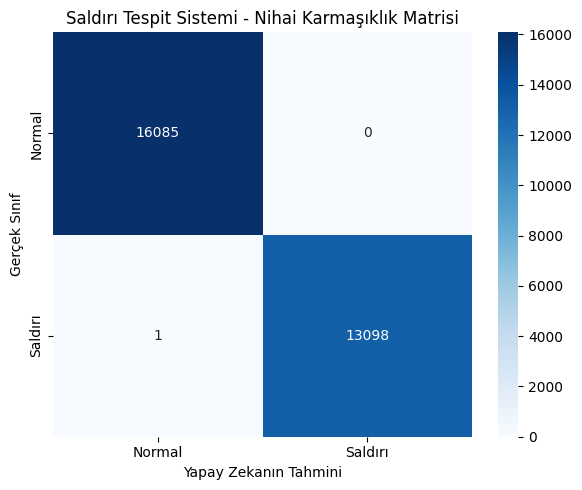

C:\Users\ZWAGE\AppData\Local\Temp\ipykernel_3164\3185188779.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


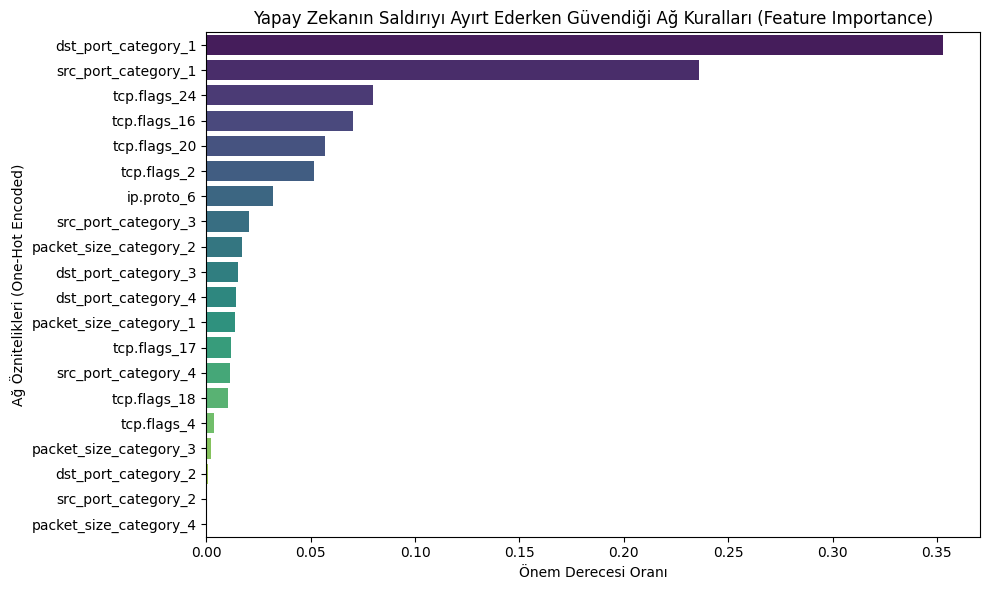

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Veri Setinin Yüklenmesi
VERI_YOLU = "C:/labs/data/islenmis/perfect_dataset_for_ml.csv"
print(f"[*] Siber Güvenlik odaklı nihai veri seti yükleniyor: {VERI_YOLU}")

if not os.path.exists(VERI_YOLU):
    raise FileNotFoundError(f"HATA: {VERI_YOLU} bulunamadı! Lütfen veri önişleme adımını doğru çalıştırdığınızdan emin olun.")

df_final = pd.read_csv(VERI_YOLU)
print(f"[+] Veri seti başarıyla yüklendi. Toplam Satır: {len(df_final)}")

# 2. Kategorik Alanların Doğru Veri Tipine Dönüştürülmesi
# Modelin sayısal büyüklük tuzağına düşmesini engellemek için kimlik belirten kolonları string yapıyoruz
categorical_cols = ['ip.proto', 'tcp.flags', 'src_port_category', 'dst_port_category', 'packet_size_category']
for col in categorical_cols:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype(str)

print("[+] Belirlenen ağ öznitelikleri başarıyla kategorik formata getirildi.")

# 3. Özellik Seçimi ve Araç Tabanlı Ezber (Window Size) Filtresi
# Hping3 imzasını ezberlememesi için 'tcp.window_size_value' kolonunu eğitime sokmuyoruz!
X = df_final.drop(columns=['label', 'tcp.window_size_value'], errors='ignore')

# Kategorik verileri yapay zekanın anlayacağı 0 ve 1 matrislerine (One-Hot Encoding) dönüştürüyoruz
X = pd.get_dummies(X, drop_first=True)
y = df_final['label']

print(f"[+] Eğitime girecek nihai özellik matrisi (Shape): {X.shape}")
print(f"[+] Eğitime dahil edilen öznitelikler: {X.columns.tolist()}")

# 4. Eğitim ve Test Veri Setlerinin Ayrılması (Train / Test Split)
# stratify=y kullanarak her iki sette de %50-%50 dengesini koruyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"[+] Veriler bölündü -> Eğitim Seti: {X_train.shape[0]} satır, Test Seti: {X_test.shape[0]} satır.")

# 5. Dengeli ve Genellenebilir Random Forest Modelinin Eğitilmesi
# max_depth=8 ile modelin aşırı derine inip veriyi tamamen ezberlemesini (overfitting) engelliyoruz
# n_jobs=-1 ile tüm işlemci çekirdeklerini aktif ederek eğitimi hızlandırıyoruz
print("\n[*] Random Forest modeli gerçek dünya kurallarına göre eğitiliyor, lütfen bekleyin...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("[+] Model eğitimi başarıyla tamamlandı!")

# 6. Tahmin Adımı ve Performans Analizi
y_pred = rf_model.predict(X_test)

# 7. Akademik Metriklerin Raporlanması
print("\n======================= NİHAİ PERFORMANS RAPORU =======================")
print(f"Genel Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred):.4f}")
print("\nSınıflandırma Metrik Detayları (Classification Report):")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Saldırı (1)']))

# 8. Görsel Karmaşıklık Matrisi (Confusion Matrix) Çizimi
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Saldırı'], yticklabels=['Normal', 'Saldırı'])
plt.title('Saldırı Tespit Sistemi - Nihai Karmaşıklık Matrisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Yapay Zekanın Tahmini')
plt.tight_layout()
plt.show()

# 9. Özellik Önem Dereceleri (Feature Importances) Çizimi
# Modelin kararları verirken hangi ağ özelliklerine güvendiğini ortaya çıkarıyoruz
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Yapay Zekanın Saldırıyı Ayırt Ederken Güvendiği Ağ Kuralları (Feature Importance)")
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.xlabel('Önem Derecesi Oranı')
plt.ylabel('Ağ Öznitelikleri (One-Hot Encoded)')
plt.tight_layout()
plt.show()

In [4]:
import joblib

# Eğitilmiş modeli ve One-Hot Encoding sütun yapısını kaydediyoruz
joblib.dump(rf_model, "C:/labs/data/islenmis/cyber_rf_model.pkl")
joblib.dump(X.columns.tolist(), "C:/labs/data/islenmis/model_columns.pkl")

print("[+] Model ve sütun yapısı başarıyla 'cyber_rf_model.pkl' olarak kaydedildi!")

[+] Model ve sütun yapısı başarıyla 'cyber_rf_model.pkl' olarak kaydedildi!


In [7]:
from scapy.all import show_interfaces
show_interfaces()

Source   Index  Name                                  MAC                    IPv4             IPv6                     
libpcap  1      Software Loopback Interface 1         00:00:00:00:00:00      127.0.0.1        ::1                      
libpcap  10     Microsoft Wi-Fi Direct Virtual Adap_  ce:5e:f8:83:69:b5      169.254.4.203    fe80::237d:688e:1989:6da8
libpcap  11     Microsoft Wi-Fi Direct Virtual Adap_  ce:5e:f8:83:79:a5      169.254.221.119  fe80::2a14:dbff:2d9:b660 
libpcap  16     TAP-Windows Adapter V9 for OpenVPN _  00:ff:7a:b1:8c:40      169.254.148.7    fe80::c458:b53a:4332:61ed
libpcap  22     WAN Miniport (IPv6)                                                                                    
libpcap  25     RZ608 Wi-Fi 6E 80MHz                  CloudNetwork:83:49:95  192.168.0.26     fe80::6b2a:6882:d43a:a77a
libpcap  3      OpenVPN Data Channel Offload                                 169.254.4.47     fe80::6dab:ff8:f579:9445 
libpcap  4      WAN Miniport (Network Mo

In [6]:
pip install scapy

  Using cached scapy-2.7.0-py3-none-any.whl.metadata (5.8 kB)
Using cached scapy-2.7.0-py3-none-any.whl (2.6 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\ZWAGE\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip
